In [1]:
# --- Check and install PuLP if not present ---
try:
    import pulp
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pulp"])
    import pulp


print(pulp.listSolvers(onlyAvailable=True))
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pulp import LpProblem, LpVariable, LpBinary, LpMinimize, lpSum
import itertools


['PULP_CBC_CMD', 'HiGHS']


In [2]:
def print_vec(vector_2n):
    """
    Prints a binary vector of length 2N in two aligned rows.

    Args:
        vector_2n: A list or array of length 2N (must be an even length).
    """
    if len(vector_2n) % 2 != 0:
        print("Error: The vector length must be even (2N).")
        return

    N = len(vector_2n) // 2
    
    # Extract the two halves
    top_row = vector_2n[:N]
    bottom_row = vector_2n[N:]
    
    # Determine the maximum width needed for an element (for alignment)
    # Assuming elements are single-digit binaries, width is 1. If not, calculate max width.
    element_width = 1 
    
    # Print the top row
    for element in top_row:
        print(f"{element:^{element_width}}", end=" ")
    print() # Newline for the second row

    # Print the bottom row with the same alignment and spacing
    for element in bottom_row:
        print(f"{element:^{element_width}}", end=" ")
    

# --- Example Usage ---
binary_vector = [1, 0, 1, 1, 0, 1, 0, 0] # Length 2N = 8, so N = 4

print("Original vector:", binary_vector)
print("\nFormatted output (N=4):")
print_vec(binary_vector)

# Another example with N=2
binary_vector_4 = [1, 0, 0, 1]
print("\nFormatted output (N=2):")
print_vec(binary_vector_4)




Original vector: [1, 0, 1, 1, 0, 1, 0, 0]

Formatted output (N=4):
1 0 1 1 
0 1 0 0 
Formatted output (N=2):
1 0 
0 1 

In [3]:

def make_nonzero_BIP(num_vars, num_constraints, seed=357):
    """
    Generate a minimization BIP with nonzero optimal solution.
    Ensures all-zero x is infeasible (b > 0) and feasible x with 1s exists.
    """
    rng = np.random.RandomState(seed + num_vars)

    c = rng.randint(1, 20, size=num_vars)  # positive costs
    A = rng.randint(0, 10, size=(num_constraints, num_vars))

    # Choose a feasible x with some 1s
    x_feasible = rng.randint(0, 2, size=num_vars)
    if x_feasible.sum() < 2:
        # ensure at least two 1's for stronger structure
        ones = rng.choice(num_vars, size=2, replace=False)
        x_feasible[ones] = 1

    # Set b so that x_feasible satisfies A x >= b
    b = A.dot(x_feasible)
    # Add positive RHS so x=0 is infeasible
    b = np.maximum(b - rng.randint(0, 3, size=b.shape), 1)

    return c, A, b, x_feasible

# --- Example test ---
def solve_bip_normally(c, A, b):
    N = len(c)
    model = pulp.LpProblem("BIP", pulp.LpMinimize)
    x = [pulp.LpVariable(f"x{i}", cat='Binary') for i in range(N)]

    model += pulp.lpSum(c[i] * x[i] for i in range(N))
    for j in range(len(A)):
        model += pulp.lpSum(A[j][i] * x[i] for i in range(N)) >= int(b[j])
    model += pulp.lpSum(x[i] for i in range(N)) >= 1  # coverage constraint

    model.solve(pulp.PULP_CBC_CMD(msg=False))
    x_val = [int(pulp.value(xi)) for xi in x]
    obj = pulp.value(model.objective)
    return pulp.LpStatus[model.status], x_val, obj




In [4]:
c, A, b, x_feas = make_nonzero_BIP(5, 5)
status, x_opt, obj = solve_bip_normally(c, A, b)
print("c =", c)
print("b =", b)
print("A =\n", A)
print("known feasible =", x_feas)
print("Optimal:", x_opt, "Obj =", obj, "Status =", status)


c = [ 2  7 16  7 18]
b = [11  7 24 19 27]
A =
 [[7 2 4 0 2]
 [5 1 7 2 0]
 [9 9 4 5 1]
 [1 3 1 7 8]
 [7 9 3 9 4]]
known feasible = [1 1 0 1 1]
Optimal: [1, 1, 0, 1, 1] Obj = 34.0 Status = Optimal


In [5]:
# --- Generate valid vectors ---
def generate_valid_vectors(N):
    """Generate all 0/1 lists with the constraint: if vec[i] == 1, then vec[N+i] must be 1."""
    for vec in itertools.product([0, 1], repeat=2 * N):
        if all(not (vec[i] == 1 and vec[i + N] == 0) for i in range(N)):
            yield list(vec)  # convert tuple → mutable list



# --- Define your binary integer program ---
def solve_bip(vec, c, A, b):
    """
    Solve a binary integer program with bounds determined by vec.
    """
    N = len(c)
    model = LpProblem("BIP", LpMinimize)

    # Binary variables
    x = [LpVariable(f"x{i}", cat=LpBinary) for i in range(N)]

    # Apply lower/upper bounds from vec
    for i in range(N):
        x[i].lowBound = vec[i]
        x[i].upBound = vec[i + N]

    # Objective: minimize cᵀx
    model += lpSum(c[i] * x[i] for i in range(N))

    # Constraints: A x ≤ b
    for j in range(len(A)):
        model += lpSum(A[j][i] * x[i] for i in range(N)) >= b[j]

    # Solve
    output = model.solve(pulp.PULP_CBC_CMD(msg=False))

    return pulp.LpStatus[output],pulp.value(model.objective)


# --- Initialize global structures ---
Q = defaultdict(lambda: defaultdict(float))
v = defaultdict(float)
results = {}
bound_change = defaultdict(float)



In [6]:
# --- Q-learning Value Function ---
def value_function(vec):
    """
    Update Q-values and value function v for a given state vector vec.
    vec: list of length 2*N representing current branching state.
    """
    if  v[tuple(vec)] == float('-inf'):
        return 0.0
    N = len(vec) // 2
    vecL = vec.copy()
    vecR = vec.copy()

    diff_sum = 0.0  # <-- track average diff for plotting
    for i in range(N):
        # Left action: fix variable i to 0
        vecL[i] = 0
        vecL[i + N] = 0
        # Right action: fix variable i to 1
        vecR[i] = 1
        vecR[i + N] = 1
        
        
        # Compute Q-values
        diffL = (results.get(tuple(vec), 0.0) - results.get(tuple(vecL), 0.0))** 2
        diffR = (results.get(tuple(vec), 0.0) - results.get(tuple(vecR), 0.0))** 2

        diff_sum += (diffL + diffR) / 2.0  # average over both branches

        Q[tuple(vec)][(i, 'L')] = diffL +  v.get(tuple(vecL), 0.0)
        Q[tuple(vec)][(i, 'R')] = diffR +  v.get(tuple(vecR), 0.0)

    # Update value function v
    #v_delta = v[tuple(vec)]
    v[tuple(vec)] = max(Q[tuple(vec)].values(), default=0.0)
    #delta = max(delta,abs(v_delta - v[tuple(vec)]))
    # Return mean of average differences for this vec
    #return v[tuple(vec)],diff_sum / N if N > 0 else 0.0
    return diff_sum / N if N > 0 else 0.0


Objective coefficients (c): [ 2  7 16  7 18]

Constraint matrix (A):
 [[7 2 4 0 2]
 [5 1 7 2 0]
 [9 9 4 5 1]
 [1 3 1 7 8]
 [7 9 3 9 4]]

RHS vector (b): [11  7 24 19 27]
Number of binary variables: 5


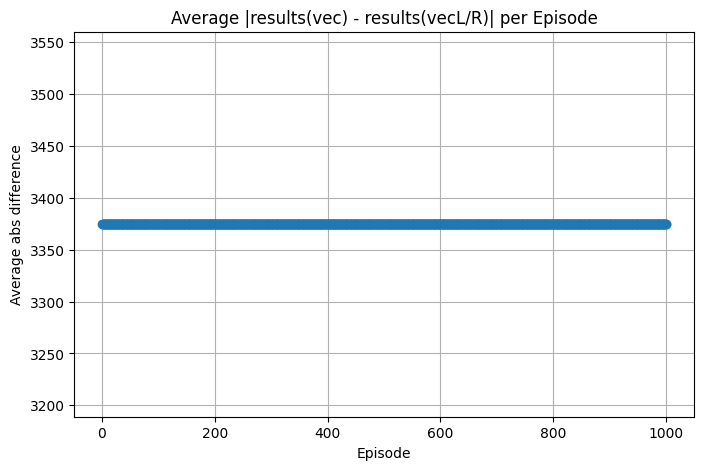


vec         Value
------------------------------
0 0 0 0 0 
0 0 0 0 0    -inf
 
0 0 0 0 0 
0 0 0 0 1    -inf
 
0 0 0 0 0 
0 0 0 1 0    -inf
 
0 0 0 0 0 
0 0 0 1 1    -inf
 
0 0 0 0 0 
0 0 1 0 0    -inf
 
0 0 0 0 0 
0 0 1 0 1    -inf
 
0 0 0 0 0 
0 0 1 1 0    -inf
 
0 0 0 0 0 
0 0 1 1 1    -inf
 
0 0 0 0 0 
0 1 0 0 0    -inf
 
0 0 0 0 0 
0 1 0 0 1    -inf
 
0 0 0 0 0 
0 1 0 1 0    -inf
 
0 0 0 0 0 
0 1 0 1 1    -inf
 
0 0 0 0 0 
0 1 1 0 0    -inf
 
0 0 0 0 0 
0 1 1 0 1    -inf
 
0 0 0 0 0 
0 1 1 1 0    -inf
 
0 0 0 0 0 
0 1 1 1 1    -inf
 
0 0 0 0 0 
1 0 0 0 0    -inf
 
0 0 0 0 0 
1 0 0 0 1    -inf
 
0 0 0 0 0 
1 0 0 1 0    -inf
 
0 0 0 0 0 
1 0 0 1 1    -inf
 
0 0 0 0 0 
1 0 1 0 0    -inf
 
0 0 0 0 0 
1 0 1 0 1    -inf
 
0 0 0 0 0 
1 0 1 1 0    -inf
 
0 0 0 0 0 
1 0 1 1 1    -inf
 
0 0 0 0 0 
1 1 0 0 0    -inf
 
0 0 0 0 0 
1 1 0 0 1    -inf
 
0 0 0 0 0 
1 1 0 1 0    -inf
 
0 0 0 0 0 
1 1 1 0 0    -inf
 
0 0 0 0 0 
1 1 1 0 1    -inf
 
0 0 0 0 0 
1 1 1 1 0    -inf
 
0 0 0 0 1 
0 0 0 0 1

In [7]:
import numpy as np
# --- Define a small test instance ---
c, A, b, x_feas = make_nonzero_BIP(5, 5)
N = len(c)
print("Objective coefficients (c):", c)
print("\nConstraint matrix (A):\n", A)
print("\nRHS vector (b):", b)

print("Number of binary variables:", N)


# Solving the optimization problem corresponding to each state
for vec in generate_valid_vectors(N):
    feas,obj_val = solve_bip(vec, c, A, b)
    if feas == 'Infeasible':
             #obj_val = float('-inf')
             v[tuple(vec)] = float('-inf')
    results[tuple(vec)] = obj_val
        
'''
for vec in generate_valid_vectors(N):
        vecL = vec.copy()
        vecR = vec.copy()
        for i in range(N):
             # Left action: fix variable i to 0
            vecL[i] = 0
            vecL[i + N] = 0
            # Right action: fix variable i to 1
            vecR[i] = 1
            vecR[i + N] = 1
            lb_change = (results.get(tuple(vec), 0.0) - results.get(tuple(vecR), 0.0)) + (results.get(tuple(vec), 0.0) - results.get(tuple(vecL), 0.0))
            bound_change[tuple(vec)] = (lb_change / 2) + bound_change[tuple(vecL)] + bound_change[tuple(vecR)]
            
'''

# --- Main Learning Loop ---
avg_diffs_per_episode = []

for episode in range(1000):
    vec_diffs = []
    for vec in generate_valid_vectors(N):
        avg_diff_vec = value_function(vec)
        vec_diffs.append(avg_diff_vec)

    # Mean of all vec differences for this episode
    avg_diffs_per_episode.append(sum(vec_diffs) / len(vec_diffs))

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(range(1, 1001), avg_diffs_per_episode, marker='o', linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Average abs difference")
plt.title("Average |results(vec) - results(vecL/R)| per Episode")
plt.grid(True)
plt.show()



# --- Print Final Value Function ---
print("\nvec".ljust(12), "Value")
print("-" * 30)
for vec, value in v.items():
    print_vec(vec)
    print(f"   {value}")
    print(" ")  


In [8]:
# --- Post-Learning Argmax Extraction ---
final_argmax = {}
for vec, actions in Q.items():
    if actions:
        best_action = max(actions, key=actions.get)
        final_argmax[vec] = best_action
    else:
        final_argmax[vec] = None

# --- Print Results ---
print("\nFinal Value Function and Best Actions:")
print("vec".ljust(15), "Value".ljust(10), "Best Action")
print("-" * 55)
for vec, best_action in final_argmax.items():
    best_val = Q[vec][best_action] if best_action else 0.0
    print_vec(vec)
    print(f"         {best_val}         {best_action}")
    #print(f"   {best_action}")
    print(" ") 
    #print(f"{str(vec).ljust(25)} {str(round(best_val, 4)).ljust(10)} {best_action}")

visited = set()  

def lb_change(vec):
    if v[tuple(vec)] == float('-inf'):
         return 0.0
    if tuple(vec) in bound_change or tuple(vec) in visited:
        return bound_change[tuple(vec)]
    
    visited.add(tuple(vec))
    if bound_change[tuple(vec)] != 0:
         return bound_change[tuple(vec)]
    action = final_argmax.get(tuple(vec))
    index, direction = action
    vecD = vec.copy()
    if direction== 'L':
            vecD[index] = 0
            vecD[index + N] = 0
    else:
            vecD[index] = 1
            vecD[index + N] = 1
            
        #lb_change = (results.get(tuple(vec), 0.0) - results.get(tuple(vecR), 0.0)) + (results.get(tuple(vec), 0.0) - results.get(tuple(vecL), 0.0))
    bound_change[tuple(vec)] = abs(results.get(tuple(vec), 0.0) - results.get(tuple(vecD), 0.0)) + lb_change(vecD)
    return bound_change[tuple(vec)]

     

for vec in generate_valid_vectors(N):
    lb_change(vec)

print("\nvec".ljust(8), "Bound Change")
print("-" * 30)
for vec, change in bound_change.items():
    print_vec(vec)
    print(f"   {change}")
    print(" ")  
            



Final Value Function and Best Actions:
vec             Value      Best Action
-------------------------------------------------------
0 0 0 0 0 
1 1 0 1 1          256.0         (0, 'R')
 
0 0 0 0 0 
1 1 1 1 1          256.0         (0, 'R')
 
0 0 0 0 1 
1 1 0 1 1          256.0         (0, 'R')
 
0 0 0 0 1 
1 1 1 1 1          256.0         (0, 'R')
 
0 0 0 1 0 
1 1 0 1 1          256.0         (0, 'R')
 
0 0 0 1 0 
1 1 1 1 1          256.0         (0, 'R')
 
0 0 0 1 1 
1 1 0 1 1          256.0         (0, 'R')
 
0 0 0 1 1 
1 1 1 1 1          256.0         (0, 'R')
 
0 0 1 0 0 
1 1 1 1 1          0.0         (0, 'R')
 
0 0 1 0 1 
1 1 1 1 1          0.0         (0, 'R')
 
0 0 1 1 0 
1 1 1 1 1          0.0         (0, 'R')
 
0 0 1 1 1 
1 1 1 1 1          0.0         (0, 'R')
 
0 1 0 0 0 
1 1 0 1 1          256.0         (0, 'R')
 
0 1 0 0 0 
1 1 1 1 1          256.0         (0, 'R')
 
0 1 0 0 1 
1 1 0 1 1          256.0         (0, 'R')
 
0 1 0 0 1 
1 1 1 1 1          256.0         (0, 

In [1]:
def solve_bip_policy(vec, c, A, b):
    """
    Solve a binary integer program with bounds determined by policy.
    """
    N = len(c)
    action = final_argmax.get(tuple(vec))
    index, direction = action
    prob = LpProblem("BIP", LpMinimize)
    

    # Binary variables
    x = [LpVariable(f"x{i}", cat=LpBinary) for i in range(N)]

    prev_vec = vec.copy()
    
    for i in range(N):
        if i == index:
            continue
        x[i].lowBound = vec[i]
        x[i].upBound = vec[i + N]



    # Apply lower/upper bounds from action
    if direction == "L":
        #x[index].lowBound = 0
        #x[index].upBound = 0
        vec[index] = 0
        vec[index + N] = 0
    elif direction == "R":
        #x[index].lowBound = 1
        #x[index].upBound = 1
        vec[index] = 1
        vec[index + N] = 1
    
    print(f"Current State :") #{str(vec).ljust(25)} {action}")
    print_vec(vec)
    print(f"               {action}")
    print(" ") 
    
    print(f"\nValue at Current State = {results[tuple(vec)]}")
    '''# Objective: minimize cᵀx
    prob += lpSum(c[i] * x[i] for i in range(N))

    # Constraints: A x ≤ b
    for j in range(len(A)):
        prob += lpSum(A[j][i] * x[i] for i in range(N)) <= b[j]

    # Solve
    #status = prob.solve(pulp.HiGHS_CMD(msg=False))
    status = prob.solve(pulp.PULP_CBC_CMD(msg=False))
    action = final_argmax.get(tuple(vec))
    
    solution = {var.name: var.value() for var in prob.variables()}
    print(f"Solution at Current State", solution)'''
    
    if v[tuple(vec)] == float('-inf'):
        status_str = 'Infeasible'
        return status_str
    merged = []
    for i in range(N):
        if vec[i] == vec[i + N]:
            merged.append(vec[i])
        else:
             status_str = 'Unrolling'
             return status_str
            
 
    if obj == results[tuple(vec)] and x_opt == merged:
        status_str = 'Optimal'
        print("Optimal State:", vec)
        print("\nObjective:", results[tuple(vec)])
        return status_str
        '''for v in prob.variables():
            print(f"{v.name} = {v.varValue}")'''
    
     
    
        
    

    

       
   
    






In [2]:
import random
print("Objective coefficients (c):", c)
print("\nConstraint matrix (A):\n", A)
print("\nRHS vector (b):", b)
N = len(c)
#valid_vectors = list(generate_valid_vectors(N))
#vec = random.choice(valid_vectors)
vec = [0]*N + [1]*N
action = final_argmax.get(tuple(vec))
print(f"Initial State : " ) #{str(vec).ljust(25)} {action}")
print_vec(vec)
print(f"               {action}")
print(" ") 
while True:
    # Solve your problem
    status_str = solve_bip_policy(vec, c, A, b)

    if status_str in ['Optimal','Infeasible']:
        print(f"Stopping: {status_str}")
        break  # exit the loop
    else:
        print(f"Solver returned {status_str}, retrying...")
        # Optional: do something before retrying, e.g., change parameters

    


NameError: name 'c' is not defined